#### Data Cleaning & Preparation Exercise:- Load a real dataset and clean it using Pandas. Handle missing values, remove duplicates, encode categorical variables, and scale numerical features. Save clean dataset.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('C:/Users/HP/OneDrive/Desktop/ML_Exercies/movies.csv')
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [30]:
df.shape
len(df)

9999

In [31]:
df.isnull().sum().to_json()

'{"MOVIES":0,"YEAR":644,"GENRE":80,"RATING":1820,"ONE-LINE":0,"STARS":0,"VOTES":1820,"RunTime":2958,"Gross":9539}'

In [51]:
numeric_columns = [column for column in df.select_dtypes(include=['float64','int64'])]
numeric_columns_report = {}
for column in numeric_columns:
    numeric_columns_report[column] = df[column].describe().to_dict()
    numeric_columns_report[column].update({"skewness":float(round(df[column].skew(),3))})

numeric_columns_report

{'RATING': {'count': 8179.0,
  'mean': 6.921176182907446,
  'std': 1.220232362895335,
  'min': 1.1,
  '25%': 6.2,
  '50%': 7.1,
  '75%': 7.8,
  'max': 9.9,
  'skewness': -0.702},
 'RunTime': {'count': 7041.0,
  'mean': 68.68853855986366,
  'std': 47.25805601877365,
  'min': 1.0,
  '25%': 36.0,
  '50%': 60.0,
  '75%': 95.0,
  'max': 853.0,
  'skewness': 3.642}}

In [56]:
df['GENRE'].nunique()

510

In [ ]:
categorical_columns = [column for column in df.select_dtypes(include=['str','object'])]
categorical_columns_report = {}
for column in categorical_columns:
    categorical_columns_report[column] = {"num_unique_values":df[column].nunique()}
    categorical_columns_report[column].update({"most_frequent":df[column].value_counts().index[0]})
    categorical_columns_report[column].update({"frequent_count":int(df[column].value_counts().iloc[0])})
categorical_columns_report

{'MOVIES': {'num_unique_values': 6817,
  'most_frequent': ' Bleach: Burîchi',
  'frequent_count': 65},
 'YEAR': {'num_unique_values': 438,
  'most_frequent': '(2020– )',
  'frequent_count': 892},
 'GENRE': {'num_unique_values': 510,
  'most_frequent': '\nComedy            ',
  'frequent_count': 852},
 'ONE-LINE': {'num_unique_values': 8688,
  'most_frequent': '\nAdd a Plot\n',
  'frequent_count': 1265},
 'STARS': {'num_unique_values': 7877,
  'most_frequent': '\n',
  'frequent_count': 456},
 'VOTES': {'num_unique_values': 4129,
  'most_frequent': '7',
  'frequent_count': 35},
 'Gross': {'num_unique_values': 332,
  'most_frequent': '$0.01M',
  'frequent_count': 22}}

In [92]:
df.shape

(461, 31)

In [19]:
def removing_the_outliers(df, column: str):

    df[column] = pd.to_numeric(df[column], errors='coerce')

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR

    total_outliers = df[
        (df[column] > upper_limit) | (df[column] < lower_limit)
    ].shape[0]

    return total_outliers

In [21]:
print(removing_the_outliers(df,column='GENRE'))

0


ValueError: List of boxplot statistics and `positions` values must have same the length

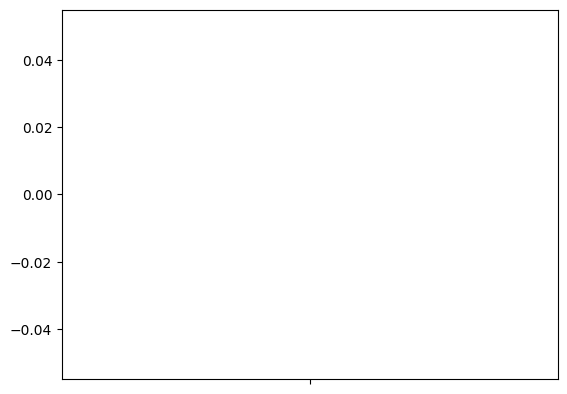